# VII. payments.csv — Thanh toán


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

payments_df['payment_value'] = pd.to_numeric(payments_df['payment_value'], errors='coerce')
payments_df['installments'] = pd.to_numeric(payments_df['installments'], errors='coerce').astype('Int64')
payments_df['payment_method'] = payments_df['payment_method'].astype(str).str.strip().str.lower()
payments_df['payment_value_log1p'] = np.log1p(payments_df['payment_value'])

Data path: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/data/raw


## 1. Tổng quan


In [ ]:
payments_df.head(10)

,order_id,payment_method,payment_value,installments,payment_value_log1p
0,1,credit_card,7967.54,3,8.98
1,2,cod,71163.75,1,11.17
2,3,credit_card,33660.99,3,10.42
3,4,credit_card,53196.25,3,10.88
4,6,paypal,1597.84,1,7.38
5,7,credit_card,9800.94,12,9.19
6,8,credit_card,16187.56,6,9.69
7,9,apple_pay,32397.12,12,10.39
8,10,paypal,19886.85,1,9.90
9,13,credit_card,36037.68,3,10.49


In [ ]:
payments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             646945 non-null  int64  
 1   payment_method       646945 non-null  str    
 2   payment_value        646945 non-null  float64
 3   installments         646945 non-null  Int64  
 4   payment_value_log1p  646945 non-null  float64
dtypes: Int64(1), float64(2), int64(1), str(1)
memory usage: 25.3 MB


In [ ]:
payments_df.columns

Index(['order_id', 'payment_method', 'payment_value', 'installments',
       'payment_value_log1p'],
      dtype='str')

In [ ]:
payments_df.shape

(646945, 5)

In [ ]:
overview_df = pd.DataFrame({
    'missing_count': payments_df.isna().sum(),
    'missing_rate_%': (payments_df.isna().mean() * 100).round(2),
    'n_unique': payments_df.nunique(dropna=False)
})
overview_df

,missing_count,missing_rate_%,n_unique
order_id,0,0.00,646945
payment_method,0,0.00,5
payment_value,0,0.00,595420
installments,0,0.00,5
payment_value_log1p,0,0.00,595420


**Nhận xét:**

- **Quan sát:**
  - Bộ dữ liệu `payments` có 646.945 dòng, các cột chính đều đầy đủ dữ liệu và không xuất hiện missing values. Sau bước xử lý, bảng gồm 5 cột làm việc: `order_id`, `payment_method`, `payment_value`, `installments` và biến biến đổi `payment_value_log1p`.
  - Cấu trúc dữ liệu khá gọn và sạch: `payment_method` chỉ có 5 nhóm, `installments` chỉ có 5 mức rời rạc, còn `payment_value` là biến liên tục với độ phân giải rất cao. Đây là dấu hiệu cho thấy bảng này phù hợp cho cả EDA mô tả lẫn phân tích hành vi thanh toán theo nhóm.

- **Insights:**
  - Về chất lượng dữ liệu: `payments.csv` là một trong những bảng có mức sẵn sàng phân tích cao nhất trong bộ dữ liệu vì gần như không cần xử lý thiếu dữ liệu hay chuẩn hóa danh mục phức tạp trước khi khai thác insight.
  - Về giá trị phân tích: Vì bảng vừa có biến giá trị (`payment_value`) vừa có biến hành vi (`payment_method`, `installments`), đây là điểm rất tốt để truy vết các pattern liên quan đến mức chi tiêu, xu hướng trả góp và cấu trúc thanh toán theo từng nhóm khách hàng/đơn hàng.

- **Gợi ý hành động:**
  - Dùng `payments` làm bảng gốc để tạo các chỉ số thanh toán cốt lõi như AOV thanh toán, tỷ trọng trả góp, cơ cấu phương thức thanh toán và phân phối giá trị đơn hàng.
  - Khi ghép với `orders` hoặc `order_items`, ưu tiên khai thác các lát cắt như `payment_method x order_status`, `installments x category`, `payment_value x return_rate` để tìm ra nhóm giao dịch có rủi ro hoặc giá trị cao.


## 1.1. Phân tích đơn biến


### 1.1.1. Biến số (Numerous)


#### a. Phân phối và outlier


Da luu bieu do ket hop tai: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/payments_distribution_boxplot.png


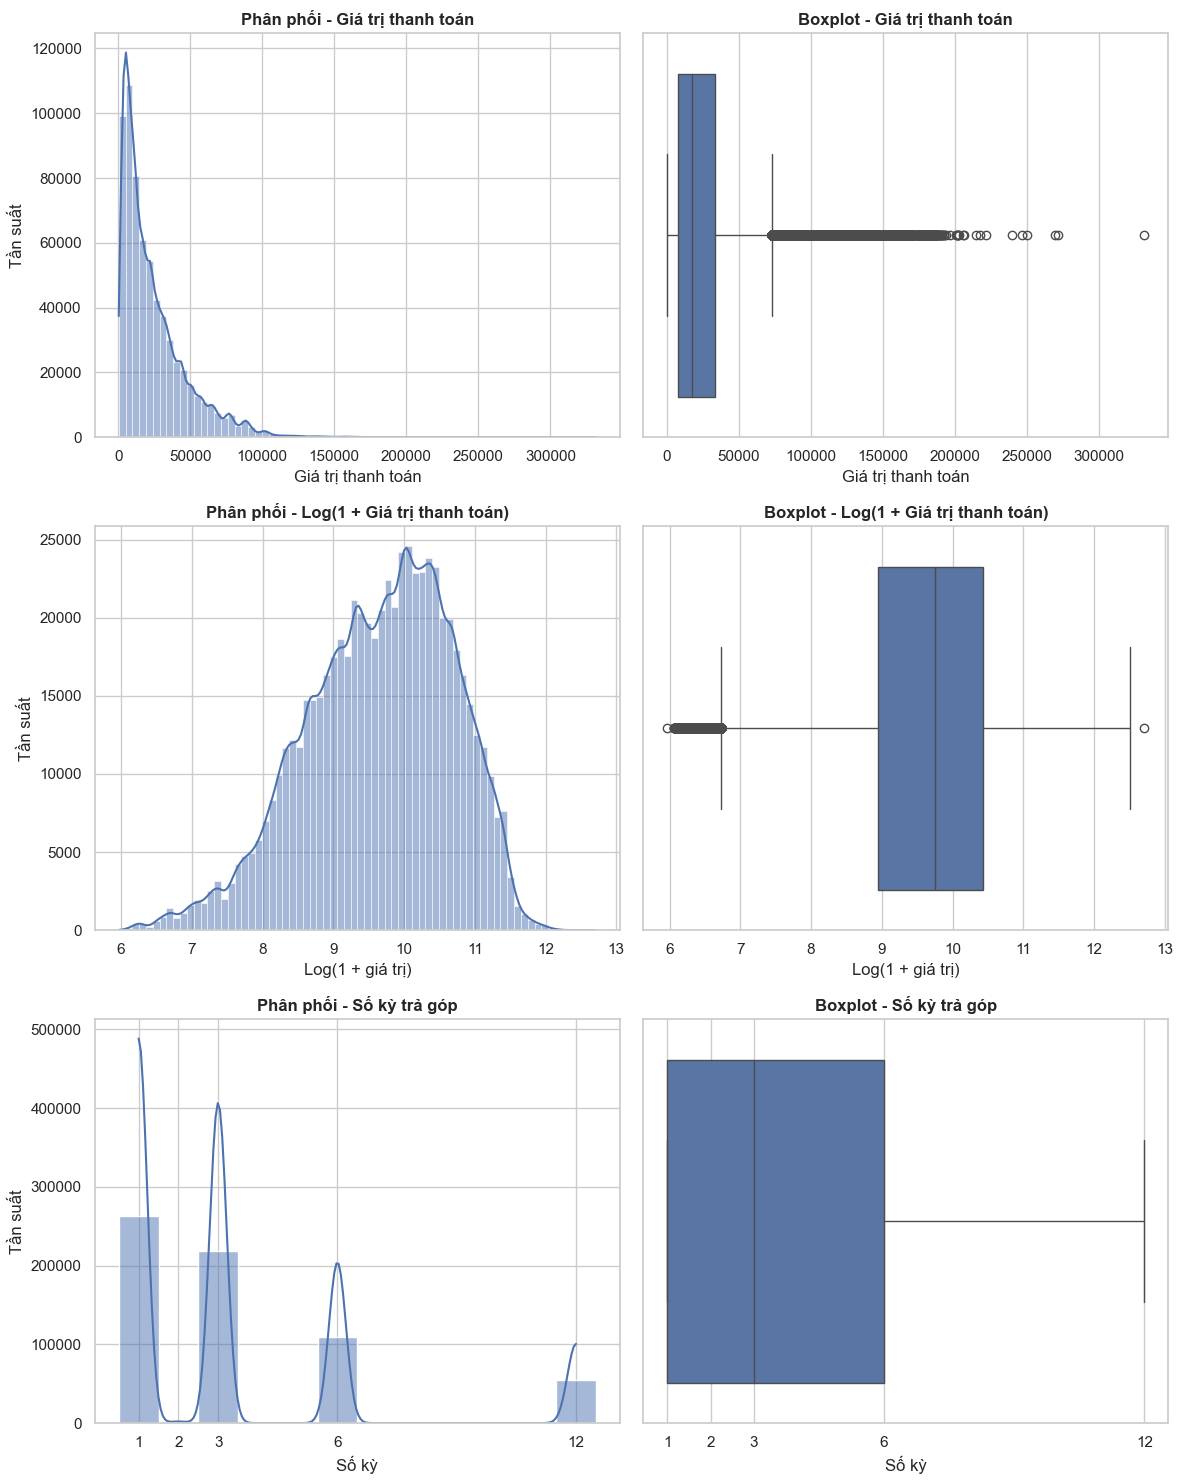

In [ ]:
col_config = {
    'payment_value': {
        'title': 'Giá trị thanh toán',
        'xlabel': 'Giá trị thanh toán',
        'hist_kwargs': {'bins': 70}
    },
    'payment_value_log1p': {
        'title': 'Log(1 + Giá trị thanh toán)',
        'xlabel': 'Log(1 + giá trị)',
        'hist_kwargs': {'bins': 70}
    },
    'installments': {
        'title': 'Số kỳ trả góp',
        'xlabel': 'Số kỳ',
        'hist_kwargs': {'discrete': True}
    }
}

con_cols_names = ['payment_value', 'payment_value_log1p', 'installments']

def format_axis(ax, col_name, values):
    if col_name == 'installments':
        ax.set_xticks(sorted(values.unique()))

def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    plt.figure(figsize=(12, 5 * n))

    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị', 'hist_kwargs': {}})
        values = df[col_name].dropna()

        ax1 = plt.subplot(n, 2, 2 * i + 1)
        sns.histplot(values, kde=True, ax=ax1, **cfg.get('hist_kwargs', {}))
        ax1.set_title(f"Phân phối - {cfg['title']}", fontweight='bold')
        ax1.set_xlabel(cfg['xlabel'])
        ax1.set_ylabel('Tần suất')
        format_axis(ax1, col_name, values)

        ax2 = plt.subplot(n, 2, 2 * i + 2)
        sns.boxplot(x=values, ax=ax2)
        ax2.set_title(f"Boxplot - {cfg['title']}", fontweight='bold')
        ax2.set_xlabel(cfg['xlabel'])
        format_axis(ax2, col_name, values)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do ket hop tai: {save_path}')

    plt.show()

plot_distribution_boxplot(
    payments_df,
    con_cols_names,
    save_path=os.path.join(IMAGES_DIR, 'payments_distribution_boxplot.png')
)

In [ ]:
q1 = payments_df['payment_value'].quantile(0.25)
q3 = payments_df['payment_value'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (payments_df['payment_value'] < lower_bound) | (payments_df['payment_value'] > upper_bound)
outlier_count = int(outlier_mask.sum())
outlier_rate = outlier_count / len(payments_df) * 100

print(f'Q1: {q1:,.2f}')
print(f'Q3: {q3:,.2f}')
print(f'IQR: {iqr:,.2f}')
print(f'Lower bound: {lower_bound:,.2f}')
print(f'Upper bound: {upper_bound:,.2f}')
print(f'So luong outlier (IQR): {outlier_count:,}')
print(f'Ty le outlier (IQR): {outlier_rate:.2f}%')

Q1: 7,681.06
Q3: 33,706.35
IQR: 26,025.29
Lower bound: -31,356.87
Upper bound: 72,744.29
So luong outlier (IQR): 30,219
Ty le outlier (IQR): 4.67%


#### b. Thống kê mô tả


In [26]:
payments_df[['payment_value', 'payment_value_log1p', 'installments']] \
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,payment_value,payment_value_log1p,installments
count,646945.00,646945.00,646945.00
mean,24238.33,9.65,3.45
std,22378.48,1.03,3.12
min,389.74,5.97,1.00
1%,1052.67,6.96,1.00
5%,2507.89,7.83,1.00
25%,7681.06,8.95,1.00
50%,17229.44,9.75,3.00
75%,33706.35,10.43,6.00
90%,55476.30,10.92,6.00


**Nhận xét:**

- **Quan sát:**
  - **Giá trị thanh toán (`payment_value`):** Biểu đồ Histogram cho thấy phân phối lệch phải rất mạnh (right-skewed). Phần lớn giao dịch tập trung ở vùng giá trị thấp đến trung bình, trong khi đuôi phải kéo dài rất xa tới mức `max = 331.570`. Thống kê mô tả xác nhận điều này với `median = 17.229`, `p75 = 33.706`, `p95 = 70.870`, `p99 = 98.076`, nhưng `mean = 24.238` bị kéo lên bởi nhóm đơn giá trị cao. Boxplot cũng cho thấy số lượng outlier tương đối rõ, khoảng 30.219 giao dịch (xấp xỉ 4,67%) theo quy tắc IQR.
  - **Số kỳ trả góp (`installments`):** Phân phối mang tính rời rạc và tập trung mạnh ở một vài mốc cố định. Mức `1 kỳ` chiếm tỷ trọng lớn nhất (262.866 giao dịch, khoảng 40,6%), tiếp theo là `3 kỳ` (218.949 giao dịch, khoảng 33,8%), rồi đến `6 kỳ` và `12 kỳ`. Mức `2 kỳ` gần như không đáng kể, cho thấy hành vi trả góp được thiết kế theo các gói chuẩn thay vì phân bổ liên tục.

- **Insights:**
  - Về `payment_value`: Doanh thu thanh toán đang được tạo ra chủ yếu từ một khối lượng lớn giao dịch giá trị thấp-trung bình, trong khi một nhóm nhỏ giao dịch high-ticket kéo đuôi phải rất dài. Điều này có nghĩa là nếu chỉ nhìn `mean payment_value`, đội ngũ vận hành rất dễ đánh giá cao quá mức mặt bằng chi tiêu thực tế của phần lớn khách hàng.
  - Về `installments`: Hành vi thanh toán không ngẫu nhiên mà bám rất sát vào các “gói trả góp chuẩn” như 1, 3, 6, 12 kỳ. Đây là tín hiệu cho thấy trải nghiệm checkout hoặc chính sách trả góp đã được chuẩn hóa khá rõ, và khách hàng có xu hướng chọn các mốc quen thuộc thay vì các phương án lẻ.
  - Về mô hình dữ liệu: Với phân phối lệch phải mạnh của `payment_value`, nếu đưa trực tiếp vào mô hình dự báo hoặc scoring, nên ưu tiên thêm biến log-transform hoặc các thước đo robust như median/quantile để giảm ảnh hưởng của đuôi ngoại lai.

- **Gợi ý hành động:**
  - Trong dashboard vận hành, nên theo dõi đồng thời `median`, `p90`, `p95`, `p99` của `payment_value` thay vì chỉ dùng `mean` để phản ánh đúng cấu trúc chi tiêu.
  - Tách riêng cohort `top 5%` hoặc `top 1% payment_value` để kiểm tra kỹ `cancelled_rate`, `return_rate` và `gross_profit`, vì chỉ cần biến động nhỏ ở nhóm này cũng có thể ảnh hưởng lớn đến doanh thu.
  - Đối với `installments`, nên đánh giá hiệu quả riêng cho từng mốc 1, 3, 6, 12 kỳ để xem kỳ hạn nào giúp tăng chuyển đổi mà vẫn giữ rủi ro tài chính ở mức chấp nhận được.


### 1.1.2. Biến phân loại (Categorical)


Da luu bieu do categorical tai: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/payments_method_distribution.png


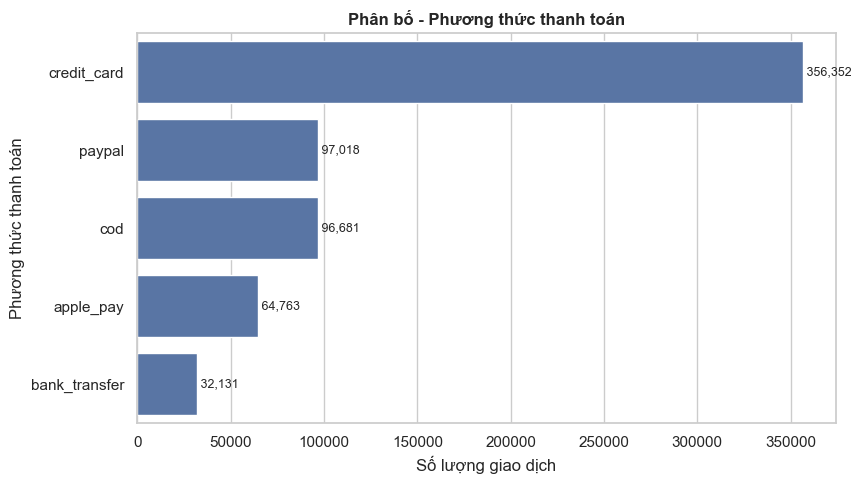

In [ ]:
COL_INFO = {
    'payment_method': {'name': 'Phương thức thanh toán', 'unit': 'giao dịch'}
}

def plot_horizontal_bar_chart(df, cate_cols_names, save_path=None):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]

        if col_name in df.columns:
            val_counts = df[col_name].fillna('khong_xac_dinh').value_counts()

            if len(val_counts) > 12:
                top11 = val_counts.iloc[:11]
                other_sum = val_counts.iloc[11:].sum()
                plot_data = pd.concat([top11, pd.Series({'khac': other_sum})])
            else:
                plot_data = val_counts

            plot_data.index = plot_data.index.astype(str)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)

            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'nhom'})
            ax.set_title(f"Phân bố - {info['name']}", fontweight='bold')
            ax.set_xlabel(f"Số lượng {info['unit']}")
            ax.set_ylabel(info['name'])

            for idx, value in enumerate(plot_data.values):
                ax.text(value, idx, f" {value:,}", va='center', fontsize=9)
        else:
            ax.set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do categorical tai: {save_path}')

    plt.show()

plot_horizontal_bar_chart(
    payments_df,
    ['payment_method'],
    save_path=os.path.join(IMAGES_DIR, 'payments_method_distribution.png')
)

In [ ]:
payment_method_stats = payments_df['payment_method'].value_counts(dropna=False).to_frame(name='count')
payment_method_stats['rate_%'] = (payment_method_stats['count'] / len(payments_df) * 100).round(2)
payment_method_stats

,count,rate_%
payment_method,,
credit_card,356352,55.08
paypal,97018,15.00
cod,96681,14.94
apple_pay,64763,10.01
bank_transfer,32131,4.97


**Nhận xét:**

- **Quan sát:**
  - Cơ cấu phương thức thanh toán tập trung rất mạnh vào `credit_card` với 356.352 giao dịch, chiếm khoảng `55,08%` toàn bộ dữ liệu. Hai nhóm theo sau là `paypal` (97.018 giao dịch) và `cod` (96.681 giao dịch), gần như ngang nhau về quy mô.
  - `apple_pay` đứng ở nhóm trung bình với 64.763 giao dịch (khoảng 10%), còn `bank_transfer` là phương thức nhỏ nhất với 32.131 giao dịch (xấp xỉ 5%). Biểu đồ cho thấy cơ cấu thanh toán không cân bằng mà bị chi phối rõ rệt bởi một phương thức chủ lực.

- **Insights:**
  - Về cấu trúc thanh toán: Hệ thống đang phụ thuộc lớn vào `credit_card`, nghĩa là bất kỳ sự cố nào liên quan đến cổng thanh toán thẻ, phí giao dịch, tỷ lệ từ chối giao dịch hoặc gian lận thẻ đều có thể tạo tác động diện rộng lên doanh thu.
  - Về chiến lược đa kênh: Việc `paypal` và `cod` cùng giữ tỷ trọng đáng kể cho thấy doanh nghiệp vẫn cần duy trì đa dạng lựa chọn thanh toán để bao phủ các nhóm khách hàng có mức độ tin cậy số hóa khác nhau. `cod` đặc biệt quan trọng ở góc nhìn trải nghiệm và niềm tin mua hàng.
  - Về tối ưu vận hành: Cơ cấu lệch mạnh này cũng gợi ý rằng các phân tích downstream như hủy đơn, hoàn tiền hay giao hàng thất bại nên luôn được tách theo `payment_method`, vì tác động kinh doanh của từng điểm nghẽn sẽ không đồng đều giữa các kênh.

- **Gợi ý hành động:**
  - Theo dõi định kỳ tỷ trọng doanh thu và số lượng giao dịch theo `payment_method` để phát hiện sớm rủi ro phụ thuộc quá mức vào `credit_card`.
  - Ưu tiên phân tích sâu `cod` và `paypal` ở các bước sau, đặc biệt trên các KPI như `cancelled_rate`, `delivery_rate` và `return_rate`, để xem liệu các phương thức này đang tạo thêm chuyển đổi hay kéo theo chi phí vận hành cao hơn.
  - Nếu hệ thống có dữ liệu phí thanh toán, nên bổ sung phân tích `payment_method x transaction_cost` để đánh giá không chỉ quy mô mà cả hiệu quả biên của từng kênh.


### 1.1.3. Biến định danh (`order_id`)


In [ ]:
order_id_summary = pd.DataFrame({
    'tong_so_dong': [len(payments_df)],
    'so_order_id_unique': [payments_df['order_id'].nunique()],
    'so_dong_order_id_bi_trung': [payments_df.duplicated(subset=['order_id']).sum()]
})
order_id_summary

,tong_so_dong,so_order_id_unique,so_dong_order_id_bi_trung
0,646945,646945,0


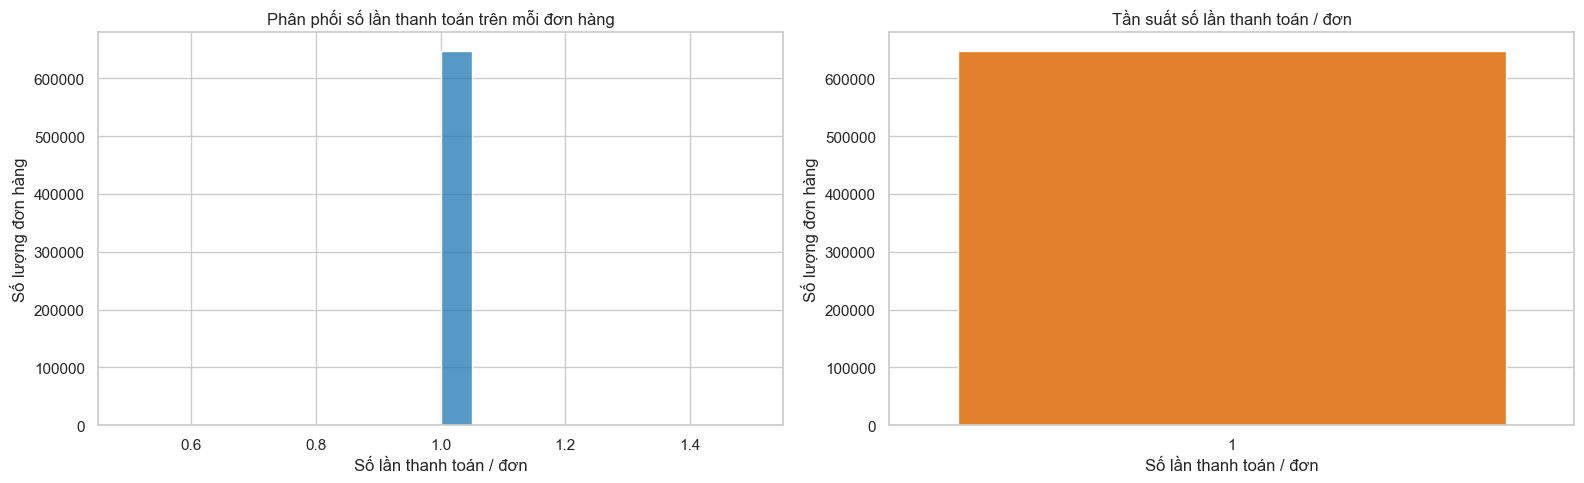

count   646945.00
mean         1.00
std          0.00
min          1.00
25%          1.00
50%          1.00
75%          1.00
90%          1.00
95%          1.00
99%          1.00
max          1.00
Name: so_lan_thanh_toan, dtype: float64

In [ ]:
payments_per_order = payments_df.groupby('order_id').size().rename('so_lan_thanh_toan').reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(payments_per_order['so_lan_thanh_toan'], bins=20, kde=False, ax=axes[0], color='tab:blue')
axes[0].set_title('Phân phối số lần thanh toán trên mỗi đơn hàng')
axes[0].set_xlabel('Số lần thanh toán / đơn')
axes[0].set_ylabel('Số lượng đơn hàng')

pp_counts = payments_per_order['so_lan_thanh_toan'].value_counts().sort_index()
sns.barplot(x=pp_counts.index, y=pp_counts.values, ax=axes[1], color='tab:orange')
axes[1].set_title('Tần suất số lần thanh toán / đơn')
axes[1].set_xlabel('Số lần thanh toán / đơn')
axes[1].set_ylabel('Số lượng đơn hàng')

plt.tight_layout()
plt.show()

payments_per_order['so_lan_thanh_toan'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

**Nhận xét:**

- **Quan sát:**
  - Phân tích trên `order_id` cho thấy mỗi dòng trong bảng `payments` tương ứng với đúng một giao dịch thanh toán và mỗi `order_id` chỉ xuất hiện một lần trong dữ liệu hiện tại. Biểu đồ phân phối số lần thanh toán trên mỗi đơn hàng vì thế co cụm hoàn toàn tại giá trị `1`.
  - Không xuất hiện pattern chia nhỏ thanh toán, retry nhiều lần hay một đơn hàng có nhiều bản ghi thanh toán đi kèm. Đây là đặc điểm khá “sạch” so với nhiều hệ thống thương mại điện tử thực tế.

- **Insights:**
  - Về grain dữ liệu: `payments.csv` đang có grain gần như `1 order = 1 payment record`, nên việc join sang `orders` ở cấp `order_id` là an toàn và không tạo rủi ro double count từ chính bảng thanh toán.
  - Về ý nghĩa nghiệp vụ: Điều này gợi ý rằng quy trình thanh toán của hệ thống khá đơn giản, chưa phản ánh các tình huống phức tạp như split payment, partial payment hoặc nhiều lần thử thanh toán thất bại rồi thành công.

- **Gợi ý hành động:**
  - Có thể dùng trực tiếp `payments_df` để join 1-1 với `orders_df` trong các phân tích tiếp theo mà không cần bước aggregate bổ sung theo `order_id`.
  - Nếu sau này có thêm log giao dịch từ payment gateway, nên đối chiếu lại để kiểm tra xem bảng hiện tại là dữ liệu thanh toán cuối cùng (successful payment only) hay đã loại bỏ các lần thử thất bại khỏi hệ thống báo cáo.


## 1.2. Phân tích 2 biến


### 1.2.1. Phân tích tương quan


In [ ]:
num_cols = ['payment_value', 'payment_value_log1p', 'installments']
corr_df = payments_df[num_cols].corr()
corr_df

,payment_value,payment_value_log1p,installments
payment_value,1.00,0.86,0.00
payment_value_log1p,0.86,1.00,0.01
installments,0.00,0.01,1.00


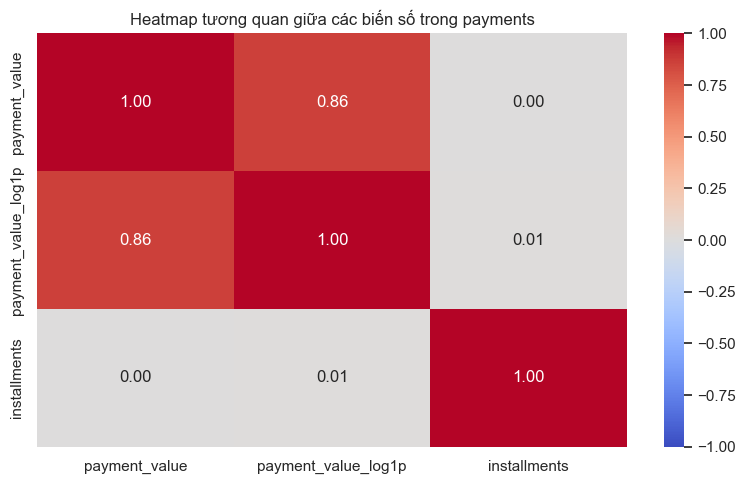

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap tương quan giữa các biến số trong payments')
plt.tight_layout()
plt.show()

### 1.2.2. Phân tích cross table


In [ ]:
crosstab_abs = pd.crosstab(payments_df['payment_method'], payments_df['installments'])
crosstab_abs

installments,1,2,3,6,12
payment_method,,,,,
apple_pay,19454,105,25915,12925,6364
bank_transfer,9892,65,12760,6245,3169
cod,96681,0,0,0,0
credit_card,107447,742,141647,71546,34970
paypal,29392,182,38627,19194,9623


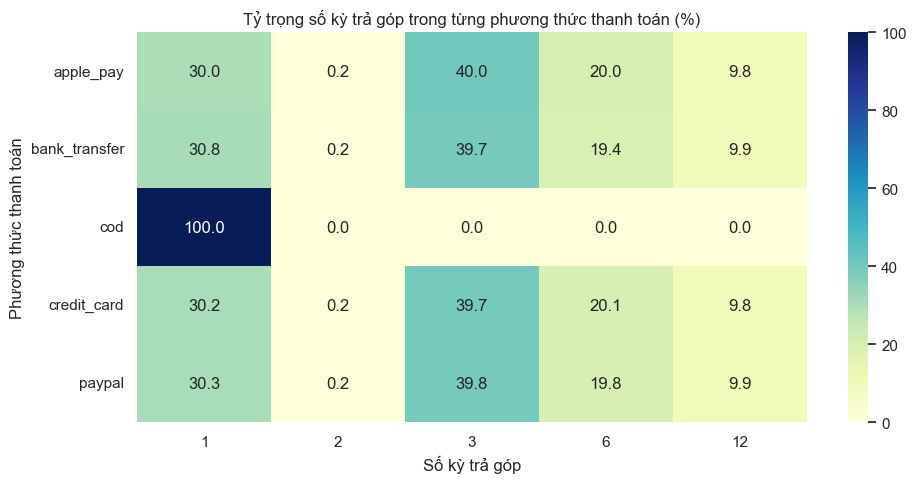

In [ ]:
crosstab_row_pct = pd.crosstab(
    payments_df['payment_method'],
    payments_df['installments'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 5))
sns.heatmap(crosstab_row_pct, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Tỷ trọng số kỳ trả góp trong từng phương thức thanh toán (%)')
plt.xlabel('Số kỳ trả góp')
plt.ylabel('Phương thức thanh toán')
plt.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - Ma trận tương quan cho thấy `payment_value` và `installments` gần như không có quan hệ tuyến tính đáng kể (`corr` xấp xỉ `0,00`). Nói cách khác, số kỳ trả góp nhiều hơn không đồng nghĩa rõ rệt với giá trị đơn hàng lớn hơn trong bộ dữ liệu này.
  - Cross table theo hàng cho thấy `cod` là trường hợp nổi bật nhất: `100%` giao dịch COD đều nằm ở `1 kỳ`, tức thanh toán một lần khi nhận hàng. Ngược lại, các phương thức số như `credit_card`, `paypal`, `apple_pay`, `bank_transfer` có cơ cấu gần như giống nhau: khoảng `30%` ở `1 kỳ`, `40%` ở `3 kỳ`, `20%` ở `6 kỳ` và gần `10%` ở `12 kỳ`.

- **Insights:**
  - Về hành vi thanh toán: Trả góp trong dữ liệu này không phải là câu chuyện của “đơn càng lớn thì càng chia nhiều kỳ”, mà giống một cấu hình sản phẩm thanh toán được áp dụng tương đối đồng đều trên hầu hết các phương thức số.
  - Về COD: Việc COD chỉ xuất hiện ở `1 kỳ` là hoàn toàn logic về nghiệp vụ, đồng thời cho thấy đây là nhóm nên được tách riêng trong các phân tích downstream vì bản chất vận hành khác hẳn các phương thức thanh toán điện tử.
  - Về thiết kế phân tích: Vì các phương thức không phải COD có mix kỳ hạn gần như giống nhau, khác biệt hiệu suất sau này nếu có nhiều khả năng sẽ đến từ chất lượng vận hành/kênh thanh toán hơn là từ bản thân cấu trúc kỳ hạn.

- **Gợi ý hành động:**
  - Ở bước phân tích đa biến, nên tách riêng hai nhóm `cod` và `non-cod` trước khi so sánh `cancelled_rate`, `return_rate` hoặc `delivery_delay` để tránh pha loãng insight.
  - Kiểm tra thêm `payment_method x installments x order_status` để xem các kỳ hạn 6 hoặc 12 tháng có kéo theo hành vi hủy/hoàn khác biệt hay không.
  - Vì tương quan tuyến tính gần như bằng 0, nếu muốn tìm ảnh hưởng của `installments` lên hiệu quả kinh doanh, nên dùng phân tích theo nhóm/cross-tab thay vì kỳ vọng vào correlation đơn thuần.


### **Câu hỏi: Xu hướng sử dụng các phương thức thanh toán thay đổi như thế nào theo thời gian và tác động của nó đến tổng doanh thu ra sao?**

#### Câu hỏi nhỏ 1: Có phương thức thanh toán nào đang cho thấy sự tăng trưởng hoặc suy giảm rõ rệt về số lượng giao dịch và giá trị thanh toán qua các tháng/năm không?

#### Câu hỏi nhỏ 2: Sự thay đổi trong cơ cấu phương thức thanh toán (ví dụ: tăng tỷ trọng credit_card hoặc giảm cod) có đồng pha với sự thay đổi của giá trị đơn hàng trung bình (AOV) theo thời gian không?

#### Câu hỏi nhỏ 3: Các đợt cao điểm doanh thu trong năm có được thúc đẩy bởi sự đột biến của một (hoặc một số) phương thức trả góp cụ thể nào đó (như kỳ hạn 6-12 tháng) kết hợp cùng phương thức thanh toán không?